# Exploratory Data Analysis (EDA) y Preprocesamiento NLP
## Proyecto: Análisis de Reputación Corporativa y Experiencia del Cliente - Ryanair

El objetivo central de este proyecto es decodificar la "Voz del Cliente" a través del procesamiento del texto libre en sus reseñas. Aplicaremos técnicas de Procesamiento de Lenguaje Natural (NLP) para clasificar el sentimiento de los pasajeros y extraer los **motivos subyacentes** de satisfacción o insatisfacción mediante el modelado de temas. Finalmente, construiremos una **Red Semántica** para analizar cómo se conectan los conceptos en la mente del consumidor.

In [1]:
# 1. IMPORTACION DE LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import re
import nltk
import itertools
from collections import Counter, defaultdict
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Descarga de recursos de NLTK
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt')

# Configuracion visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerias importadas correctamente.")

Librerias importadas correctamente.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jmedi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jmedi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jmedi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### 2. Carga y Limpieza Inicial de Datos

Ingesta del dataset de reseñas. Se realiza un tratamiento de valores nulos y se concatena el título y el cuerpo de la reseña para asegurar que no se pierde ninguna carga semántica expresada por el usuario.

In [2]:
# 2. CARGA Y LIMPIEZA INICIAL DE DATOS
ruta_archivo = '../data/raw/ryanair_reviews.csv'
df = pd.read_csv(ruta_archivo)

# Eliminar columnas residuales sin nombre
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convertir fechas a formato datetime
df['Date Published'] = pd.to_datetime(df['Date Published'], errors='coerce')

# Tratamiento de valores nulos
df['Comment title'] = df['Comment title'].fillna('')
df['Comment'] = df['Comment'].fillna('')
df['Origin'] = df['Origin'].fillna('Unknown')
df['Destination'] = df['Destination'].fillna('Unknown')

# UNION DE TEXTOS: La base absoluta de nuestro estudio
df['Full_Text'] = df['Comment title'] + ". " + df['Comment']

print(f"Dimensiones del dataset listo para analizar: {df.shape}")
print("Valores nulos en columnas clave revisados.")

Dimensiones del dataset listo para analizar: (2249, 21)
Valores nulos en columnas clave revisados.


### 3. Análisis Exploratorio de Datos (EDA): Diagnóstico Operativo

Analizamos las variables estructuradas (calificaciones numéricas) para establecer una línea base de la percepción del cliente sobre las distintas áreas de servicio operativas que Ryanair sí puede controlar, medir y mejorar.

C:\Users\jmedi\AppData\Local\Temp\ipykernel_23472\2377592103.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Overall Rating', palette='viridis', ax=axes[0])
C:\Users\jmedi\AppData\Local\Temp\ipykernel_23472\2377592103.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ratings, x='Nota Media', y='Area de Servicio', palette='magma', ax=axes[1])


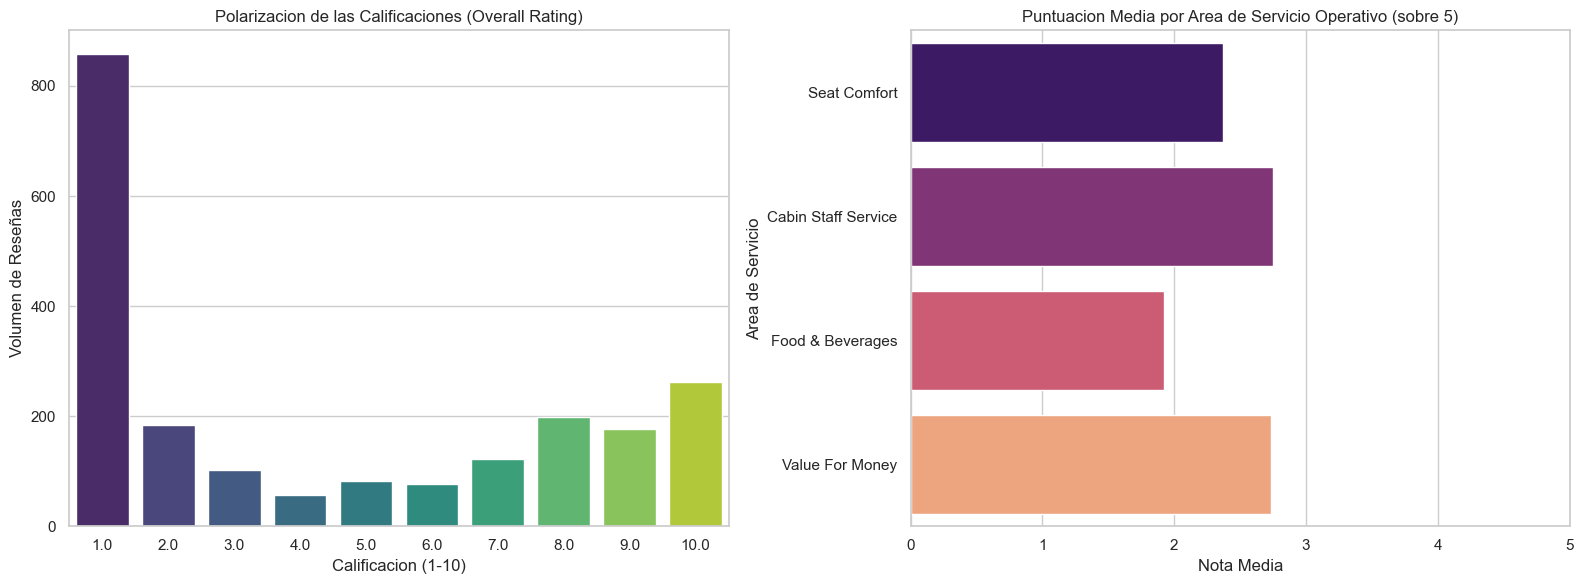

In [3]:
# 3. EDA - DIAGNOSTICO OPERATIVO

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3.1 Distribucion de la calificacion general
sns.countplot(data=df, x='Overall Rating', palette='viridis', ax=axes[0])
axes[0].set_title('Polarizacion de las Calificaciones (Overall Rating)')
axes[0].set_xlabel('Calificacion (1-10)')
axes[0].set_ylabel('Volumen de Reseñas')

# 3.2 Calificaciones por areas de negocio (Controlables por la aerolinea)
cols_ratings = ['Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Value For Money']
df_ratings = df[cols_ratings].mean().reset_index()
df_ratings.columns = ['Area de Servicio', 'Nota Media']

sns.barplot(data=df_ratings, x='Nota Media', y='Area de Servicio', palette='magma', ax=axes[1])
axes[1].set_title('Puntuacion Media por Area de Servicio Operativo (sobre 5)')
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

### 4. NLP: Limpieza de Texto, Clasificación de Temas y Sentimiento (VADER)

Aplicamos el modelo léxico VADER para clasificar la emoción general. Además, introducimos un algoritmo basado en reglas para categorizar cada reseña en uno de los "5 Pilares" de la experiencia de vuelo, permitiendo un Análisis de Sentimiento Basado en Aspectos (ABSA).

Limpiando textos...
Calculando sentimiento...


C:\Users\jmedi\AppData\Local\Temp\ipykernel_23472\2727507901.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment_Label', order=['negative', 'neutral', 'positive'], palette=['#c0392b', '#95a5a6', '#27ae60'])


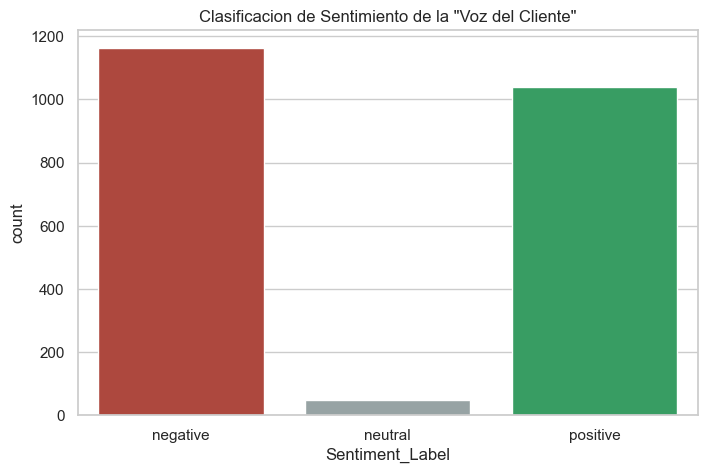

In [4]:
# 4. LIMPIEZA, SENTIMIENTO NLP Y ETIQUETADO DE TEMAS (ABSA)

# 4.1 Limpieza textual y Stopwords personalizadas
stop_words_en = set(stopwords.words('english'))
custom_stops = {'ryanair', 'flight', 'fly', 'flew', 'flights', 'airline', 'get', 'one', 'would', 'even'}
stop_words_en.update(custom_stops)

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-z\s]', '', texto)
    tokens = texto.split()
    tokens = [word for word in tokens if word not in stop_words_en and len(word) > 2]
    return ' '.join(tokens)

print("Limpiando textos...")
df['Text_Clean'] = df['Full_Text'].apply(limpiar_texto)

# 4.2 Clasificador de Temas
def categorizar_tema(texto):
    texto = texto.lower()
    temas = {
        'Personal/Tripulacion': ['staff', 'crew', 'polite', 'rude', 'helpful', 'service', 'attendant', 'personnel'],
        'Asientos/Confort': ['seat', 'legroom', 'space', 'comfortable', 'uncomfortable', 'cabin', 'sit'],
        'Precio/Valor': ['money', 'price', 'value', 'cheap', 'expensive', 'cost', 'fare', 'pay', 'charge', 'extra'],
        'Puntualidad/Retrasos': ['time', 'delay', 'late', 'ontime', 'schedule', 'waiting', 'hour', 'hours', 'delayed'],
        'Equipaje/Embarque': ['bag', 'luggage', 'suitcase', 'boarding', 'priority', 'gate', 'checkin', 'desk']
    }
    
    for tema, palabras in temas.items():
        if any(word in texto for word in palabras):
            return tema
    return 'General/Otros'

df['Tema'] = df['Text_Clean'].apply(categorizar_tema)

# 4.3 Analisis de Sentimiento con VADER
analyzer = SentimentIntensityAnalyzer()

def obtener_sentimiento(texto):
    compound = analyzer.polarity_scores(texto)['compound']
    if compound >= 0.05: return 'positive'
    elif compound <= -0.05: return 'negative'
    else: return 'neutral'

print("Calculando sentimiento...")
df['Sentiment_Score'] = df['Full_Text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
df['Sentiment_Label'] = df['Full_Text'].apply(obtener_sentimiento)

# Visualizar la distribucion del sentimiento general
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment_Label', order=['negative', 'neutral', 'positive'], palette=['#c0392b', '#95a5a6', '#27ae60'])
plt.title('Clasificacion de Sentimiento de la "Voz del Cliente"')
plt.show()

### 5. Text Mining: Extracción de Insights de Negocio (Puntos de Dolor y Fortalezas)

Una vez segmentados los textos, extraemos las palabras más frecuentes en las reseñas negativas frente a las positivas. Esto revela los motivos específicos sobre los que Ryanair debe actuar para mejorar su reputación y retención de clientes.

C:\Users\jmedi\AppData\Local\Temp\ipykernel_23472\2808352933.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_neg, x='Frecuencia', y='Palabra', palette='Reds_r', ax=axes[0])
C:\Users\jmedi\AppData\Local\Temp\ipykernel_23472\2808352933.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pos, x='Frecuencia', y='Palabra', palette='Greens_r', ax=axes[1])


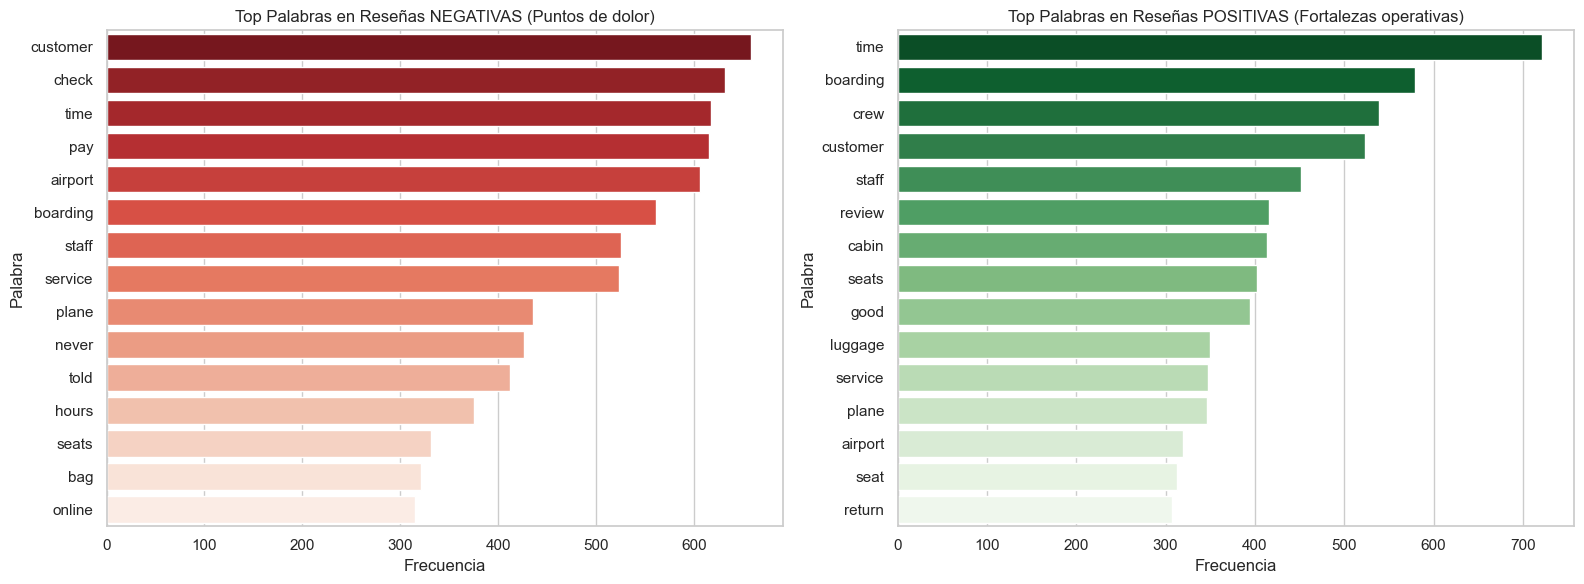

In [5]:
# 5. EXTRACCION DE INSIGHTS (WORD FREQUENCY)

def get_top_words(text_series, n=15):
    all_words = ' '.join(text_series).split()
    return Counter(all_words).most_common(n)

# Separar reseñas por sentimiento
textos_negativos = df[df['Sentiment_Label'] == 'negative']['Text_Clean']
textos_positivos = df[df['Sentiment_Label'] == 'positive']['Text_Clean']

top_neg = pd.DataFrame(get_top_words(textos_negativos), columns=['Palabra', 'Frecuencia'])
top_pos = pd.DataFrame(get_top_words(textos_positivos), columns=['Palabra', 'Frecuencia'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico Quejas (Rojo)
sns.barplot(data=top_neg, x='Frecuencia', y='Palabra', palette='Reds_r', ax=axes[0])
axes[0].set_title('Top Palabras en Reseñas NEGATIVAS (Puntos de dolor)')

# Grafico Halagos (Verde)
sns.barplot(data=top_pos, x='Frecuencia', y='Palabra', palette='Greens_r', ax=axes[1])
axes[1].set_title('Top Palabras en Reseñas POSITIVAS (Fortalezas operativas)')

plt.tight_layout()
plt.show()

### 6. Minería de Redes Semánticas (Preparación para Gephi)

Abandonamos el enfoque logístico (rutas aéreas) para construir un modelo de **Co-ocurrencia de Palabras**. 
En esta red, los nodos son conceptos clave expresados por los clientes y las aristas representan el hecho de que ambas palabras se mencionaron juntas en la misma reseña. El color (peso) de la conexión reflejará la carga emocional conjunta de esos dos conceptos, generando mapas mentales del consumidor.

In [ ]:
# 6. CONSTRUCCION DE RED SEMANTICA (CO-OCURRENCIA) Y EXPORTACION GEPHI

import os
import networkx as nx
import itertools
from collections import Counter, defaultdict

os.makedirs('../data/processed', exist_ok=True)
print("Construyendo Red Semantica de Palabras...")

# 6.1 Seleccionar las 100 palabras mas frecuentes para crear una red estructurada y sin ruido
todas_las_palabras = ' '.join(df['Text_Clean']).split()
top_100_palabras = [word for word, count in Counter(todas_las_palabras).most_common(100)]

# Diccionario para guardar las conexiones entre palabras y el sentimiento conjunto
co_occurrences = defaultdict(lambda: {'weight': 0, 'sentiment_sum': 0})

# 6.2 Escanear cada reseña para conectar palabras
for index, row in df.iterrows():
    # Obtener palabras unicas del comentario que esten en nuestro Top 100
    words = set(row['Text_Clean'].split())
    words = [w for w in words if w in top_100_palabras]
    sentimiento_comentario = row['Sentiment_Score']
    
    # Crear pares de palabras
    for w1, w2 in itertools.combinations(words, 2):
        pair = tuple(sorted([w1, w2]))
        co_occurrences[pair]['weight'] += 1
        co_occurrences[pair]['sentiment_sum'] += sentimiento_comentario

# 6.3 Construir el Grafo No Dirigido en NetworkX
G_semantico = nx.Graph()

for (w1, w2), data in co_occurrences.items():
    peso = data['weight']
    if peso > 5: 
        sentimiento_medio = data['sentiment_sum'] / peso
        
        # --- EL TRUCO INFALIBLE: ETIQUETAR LA LÍNEA ---
        if sentimiento_medio <= -0.05:
            tipo_emocion = 'Negativo'
        elif sentimiento_medio >= 0.05:
            tipo_emocion = 'Positivo'
        else:
            tipo_emocion = 'Neutro'
        # ----------------------------------------------
            
        G_semantico.add_edge(w1, w2, weight=peso, avg_sentiment=sentimiento_medio, Categoria_Emocion=tipo_emocion)

# 6.4 EL ESLABON PERDIDO: ASIGNAR EL "TEMA" A CADA NODO (PALABRA)
temas_dict = {
    'Personal/Tripulacion': ['staff', 'crew', 'polite', 'rude', 'helpful', 'service', 'attendant', 'personnel'],
    'Asientos/Confort': ['seat', 'legroom', 'space', 'comfortable', 'uncomfortable', 'cabin', 'sit'],
    'Precio/Valor': ['money', 'price', 'value', 'cheap', 'expensive', 'cost', 'fare', 'pay', 'charge', 'extra'],
    'Puntualidad/Retrasos': ['time', 'delay', 'late', 'ontime', 'schedule', 'waiting', 'hour', 'hours', 'delayed'],
    'Equipaje/Embarque': ['bag', 'luggage', 'suitcase', 'boarding', 'priority', 'gate', 'checkin', 'desk']
}

# Creamos un diccionario inverso para que Python sepa que tema le toca a cada palabra
palabra_a_tema = {}
for tema, palabras in temas_dict.items():
    for p in palabras:
        palabra_a_tema[p] = tema

# Recorremos todos los nodos (palabras) del grafo y les inyectamos su Tema
for nodo in G_semantico.nodes():
    tema_asignado = palabra_a_tema.get(nodo, 'General/Otros')
    G_semantico.nodes[nodo]['Tema'] = tema_asignado

print(f"Red Semantica construida: {G_semantico.number_of_nodes()} conceptos clave y {G_semantico.number_of_edges()} conexiones.")

# 6.5 EXPORTACION DEFINITIVA

# Exportar la nueva red semantica a Gephi (AHORA SI, CON TEMAS)
nx.write_gexf(G_semantico, '../data/processed/red_semantica_ryanair.gexf')

# Exportar datos limpios y etiquetados para el Dashboard Web
cols_dash = ['Date Published', 'Overall Rating', 'Seat Comfort', 'Cabin Staff Service', 
             'Text_Clean', 'Sentiment_Score', 'Sentiment_Label', 'Tema', 'Origin', 'Destination']
df[cols_dash].to_csv('../data/processed/ryanair_limpios_temas.csv', index=False)

print("Proceso completado con exito. Todos los archivos exportados a data/processed/")

Construyendo Red Semantica de Palabras...
Red Semantica construida: 100 conceptos clave y 4947 conexiones.
Proceso completado con exito. Todos los archivos exportados a data/processed/
